# Thermal building model
## Final Notebook


### Import section

The implemented code will use the following libraries and the dm4bem.py file for the thermal model of the proposed bulding

In [299]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import lu_factor, lu_solve
import dm4bem

### Modelling

This section presents the model of the analysed building.\
In this section is possible to select if the simulation should consider or not the controller in room 2.\
It is also possible to select the Euler explicit or implicit method.
In addition, the time step 5s is imposed to avoid numerical instability. However, there is the option to obtain the results with the time step obtained from the eigenvalues of the system.

In [300]:
# Rooms geometry
l = 3               # m length of the cubic room
L = 5
w = 0.2
H = 3

# Window geometry
l_window = 1.25
L_window = 2
w_window = 0.07

# Doors geometry
l_door = 2.00
L_door = 0.90
w_door = 0.1

# Surfaces
S_window = l_window * L_window
S_door = l_door * L_door
S_wall_total = H * (2*L + 2*w + l)            # m² surface area of wall
S_wall_1 = S_wall_total - S_door
S_wall_2 = S_wall_total - S_door - S_window
S_wall_3 = l*H

# Controller and time step
controller = True
Euler_explicit = True
imposed_time_step = True
Δt = 5    # s, imposed time step (minimum without numerical instability)

#### General parameters of the model

The model presented below has some characteristics and parameters considered to perform all the calculations. Thermal conductivities, materials density, specific heat and width. The parameters are defined for the concrete layer, the insulation layer, the window layer, the door layer and the surfaces are calculated.
 
<img src="./thermal_circuit.png" alt="Complete thermal circuit" width="500">

Air density and specific heat

In [301]:
air = {'Density': 1.2,                      # kg/m³
       'Specific heat': 1000}               # J/(kg·K)
pd.DataFrame(air, index=['Air'])

,Density,Specific heat
Air,1.2,1000


Materials and layers of the building

In [302]:
concrete = {'Conductivity': 1.740,          # W/(m·K)
            'Density': 2300.0,              # kg/m³
            'Specific heat': 880,           # J/(kg⋅K)
            'Width': w*0.8}                   # m

insulation = {'Conductivity': 0.035,        # W/(m·K)
              'Density': 55.0,              # kg/m³
              'Specific heat': 1210,        # J/(kg⋅K)
              'Width': w*0.2}                 # m

double_glass = {'Conductivity': 0.112,               # W/(m·K)
         'Density': 2500,                   # kg/m³
         'Specific heat': 1210,             # J/(kg⋅K)
         'Width': w_window,                 #m
         'Surface': S_window}               #m²

solid_wood = {'Conductivity': 0.14,               # W/(m·K)
         'Density': 2500,                   # kg/m³
         'Specific heat': 1210,             # J/(kg⋅K)
         'Width': w_door,                   # m
         'Surface': S_door}                 # m²

surfaces = {
    'Layer_out_1': S_wall_1,
    'Layer_in_1': S_wall_1,
    'Layer_out_2': S_wall_2,
    'Layer_in_2': S_wall_2,
    'Layer_out_3': S_wall_3,
    'Layer_in_3': S_wall_3,
}
 
wall = pd.DataFrame.from_dict({'Layer_out_1': concrete,
                               'Layer_in_1': insulation,
                               'Layer_out_2': concrete,
                               'Layer_in_2': insulation,
                               'Layer_out_3': concrete,
                               'Layer_in_3': insulation,
                               'Window': double_glass,
                               'Door': solid_wood},
                              orient='index')

wall['Surface'] = wall['Surface'].fillna(pd.Series(surfaces))

wall

,Conductivity,Density,Specific heat,Width,Surface
Layer_out_1,1.740,2300.0,880,0.16,38.4
Layer_in_1,0.035,55.0,1210,0.04,38.4
Layer_out_2,1.740,2300.0,880,0.16,35.9
Layer_in_2,0.035,55.0,1210,0.04,35.9
Layer_out_3,1.740,2300.0,880,0.16,9.0
Layer_in_3,0.035,55.0,1210,0.04,9.0
Window,0.112,2500.0,1210,0.07,2.5
Door,0.140,2500.0,1210,0.10,1.8


Convection coefficient

In [303]:
h = pd.DataFrame([{'in': 8., 'out': 25}], index=['h'])  # W/(m²⋅K)
h

,in,out
h,8.0,25


#### Conduction conductances

$$G_{cd} = \frac{\lambda}{w}S$$

where:

- $\lambda$ - thermal conductvity, W/(m⋅K);
- $w$ - width of the material, m;
- $S$ - surface area of the wall, m².

In [304]:
G_cd = wall['Conductivity'] / wall['Width'] * wall['Surface']
pd.DataFrame(G_cd, columns=['Conductance'])

,Conductance
Layer_out_1,417.6000
Layer_in_1,33.6000
Layer_out_2,390.4125
Layer_in_2,31.4125
Layer_out_3,97.8750
Layer_in_3,7.8750
Window,4.0000
Door,2.5200


#### Convection conductances
$$G_{cv} = {h S}$$

where:
- $h$ is the convection coefficient, W/(m²⋅K);
- $S$ - surface area of the wall, m².

In [305]:
G_wall_1 = h * wall['Surface'].iloc[0]
G_wall_2 = h * wall['Surface'].iloc[2] 
G_wall_3 = h * wall['Surface'].iloc[4] 
G_window = h * wall['Surface'].iloc[6]     
G_door = h * wall['Surface'].iloc[7]

#### Advection conductances

$$\dot{V}_a = \frac{\mathrm{ACH}}{3600} V_a$$

where:
- $\mathrm{ACH}$  air changes per hour is the air infiltration rate, 1/h;
- $3600$ - number of seconds in one hour, s/h;
- $V_a$ - volume of the air in the thermal zone, m³.

Therefore, the conductance of advection by ventilation and/or infiltration, in W/K, is:

$$G_v = \rho_a c_a \dot{V}_a$$

In [306]:
Va = (L*l*H)                   # m³, volume of air
ACH = 1                     # 1/h, air changes per hour
Va_dot = ACH / 3600 * Va    # m³/s, air infiltration

Gv = air['Density'] * air['Specific heat'] * Va_dot

#### Proportional controller

$$ q_{HVAC} = K_p (T_{i, sp} - \theta_i)$$

where:
- $K_p$ is the proportional gain of the controller, W/K;
- $T_{i, sp}$ - indoor temperature setpoint, °C (noted in majuscule because it is an *input*, i.e., independent, variable);
- $\theta_i$ - indoor temperature, °C (noted in minuscule because it is an *output*, i.e., dependent variable).

In [307]:
if controller:
    Kp = 1e4          # almost perfect controller Kp -> ∞
else:
    Kp = 0         # no controller Kp -> 0

#### Conductances in series and/or parallel

$$ G_{gs} = \frac{1}{1/G_{g,cv.out } + 1/(2 G_{g,cd})} =  
\frac{1}{\frac{1}{h_{out} S_g} + \frac{w / 2}{\lambda S_g}}
$$

In [308]:
Ggs_window = float(1 / (1 / G_window.loc['h', 'out'] + 1 / (2 * G_cd['Window'])))
Ggs_door = float(1 / (1 / G_window.loc['h', 'out'] + 1 / (2 * G_cd['Door'])))

Ggs_1 = Ggs_door                 # Room 1 has only one door
Ggs_2 = Ggs_door + Ggs_window    # Room 2 has one door and one window

#### Thermal capacities

$$C_w= m_w c_w= \rho_w c_w w_w S_w$$

where:
- $m_w = \rho_w w_w S_w$ is the mass of the wall, kg;
- $c_w$ - specific heat capacity, J/(kg⋅K);
- $\rho_w$ - density, kg/m³;
- $w_w$ - width of the wall, m;
- $S_w$ - surface area of the wall, m².

In [309]:
C = wall['Density'] * wall['Specific heat'] * wall['Surface'] * wall['Width']
pd.DataFrame(C, columns=['Capacity'])

C['Air'] = air['Density'] * air['Specific heat'] * Va
pd.DataFrame(C, columns=['Capacity'])

,Capacity
Layer_out_1,12435456.0
Layer_in_1,102220.8
Layer_out_2,11625856.0
Layer_in_2,95565.8
Layer_out_3,2914560.0
Layer_in_3,23958.0
Window,529375.0
Door,544500.0
Air,54000.0


#### Assembling the Thermal circuit

The number of nodes and flow branches are obtained from the thermal circuit.

In [310]:
# temperature nodes
nθ = 18      # number of temperature nodes
θ = [f'θ{i}' for i in range(nθ)]
print(θ)

# flow-rate branches
nq = 23     # number of flow branches
q = [f'q{i}' for i in range(nq)]
print(q)

['θ0', 'θ1', 'θ2', 'θ3', 'θ4', 'θ5', 'θ6', 'θ7', 'θ8', 'θ9', 'θ10', 'θ11', 'θ12', 'θ13', 'θ14', 'θ15', 'θ16', 'θ17']
['q0', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'q9', 'q10', 'q11', 'q12', 'q13', 'q14', 'q15', 'q16', 'q17', 'q18', 'q19', 'q20', 'q21', 'q22']


#### Capacity matrix

It is possible to neglect the air capacity, in this case, we consider the air capacity in the model

In [311]:
neglect_air_glass = False

if neglect_air_glass:
    C = np.array([0 , 0 , 0, C['Layer_out_1'], 0, C['Layer_in_1'], 0, 0, C['Layer_out_3'], 0, C['Layer_in_3'], 0, 0,
                  C['Layer_out_2'], 0, C['Layer_in_2'], 0, C['Window']])
else:
    C = np.array([C['Air'], C['Air'], 0, C['Layer_out_1'], 0, C['Layer_in_1'], 0, 0, C['Layer_out_3'], 0, C['Layer_in_3'], 0, 0,
                  C['Layer_out_2'], 0, C['Layer_in_2'], 0, C['Window']])

pd.DataFrame(C, index=θ)

,0
θ0,54000.0
θ1,54000.0
θ2,0.0
θ3,12435456.0
θ4,0.0
θ5,102220.8
θ6,0.0
θ7,0.0
θ8,2914560.0
θ9,0.0


#### A: incidence matrix

In [312]:
A = np.zeros([nq, nθ])       # n° of branches X n° of nodes

A[0,2] =  1
A[1,16] = 1
A[2,0] =  1
A[3,17] , A[3,1] = -1, 1 
A[4,17] = 1
A[5,0], A[5,6] = -1, 1
A[6,0], A[6,7] = -1, 1
A[7,11], A[7,1] = -1, 1
A[8,1], A[8,12] = -1, 1
A[9,2], A[9,3] = -1, 1
A[10,3], A[10, 4] = -1, 1
A[11,4], A[11,5] = -1, 1
A[12,5], A[12,6] = -1, 1
A[13,7], A[13,8] = -1, 1
A[14,8], A[14,9] = -1, 1
A[15,9], A[15,10] = -1, 1
A[16,10], A[16,11] = -1, 1
A[17,16], A[17,15] = -1, 1
A[18,15], A[18,14] = -1 ,1
A[19,14], A[19,13] = -1, 1
A[20,13], A[20,12] = -1, 1
A[21,1] = 1
A[22,0] = 1


pd.DataFrame(A, index=q, columns=θ)

,θ0,θ1,θ2,θ3,θ4,θ5,θ6,θ7,θ8,θ9,θ10,θ11,θ12,θ13,θ14,θ15,θ16,θ17
q0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
q1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
q2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
q3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
q4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
q5,-1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
q6,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
q7,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
q8,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
q9,0.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### G: conductance matrix

In [313]:
G = np.array(np.hstack(
    [G_wall_1['out'],
     G_wall_2['out'],
     G_door['out'],
     2*(G_door['out'] + G_window['out']),
     2*(G_door['out'] + G_window['out']),
     G_wall_1['in'],
     G_wall_3['in'],
     G_wall_3['in'],
     G_wall_2['in'],
     2*G_cd['Layer_in_1'],
     2*G_cd['Layer_in_1'],
     2*G_cd['Layer_out_1'],
     2*G_cd['Layer_out_1'],
     2*G_cd['Layer_in_3'],
     2*G_cd['Layer_in_3'],
     2*G_cd['Layer_out_3'],
     2*G_cd['Layer_out_3'],
     2*G_cd['Layer_out_2'],
     2*G_cd['Layer_out_2'],
     2*G_cd['Layer_in_2'],
     2*G_cd['Layer_in_2'],
     Gv,
     Kp]))

pd.DataFrame(G, index=q)

,0
q0,960.000
q1,897.500
q2,45.000
q3,215.000
q4,215.000
q5,307.200
q6,72.000
q7,72.000
q8,287.200
q9,67.200


#### b: temperature source vector

In [314]:
b = pd.Series(['To', 'To', 'To', 0, 'To', 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 'To', 'Ti_sp'],
              index=q)

pd.DataFrame(b, index=q)

,0
q0,To
q1,To
q2,To
q3,0
q4,To
q5,0
q6,0
q7,0
q8,0
q9,0


#### f: heat flow source vector

In [315]:
f = pd.Series([0, 0,'Φo', 0, 0, 0, 'Φo', 'Φi', 0, 0, 0, 'Φi', 'Φo', 0, 0, 0, 'Φo', 0],
              index=θ)
pd.DataFrame(f, index=θ)

,0
θ0,0
θ1,0
θ2,Φo
θ3,0
θ4,0
θ5,0
θ6,Φo
θ7,Φi
θ8,0
θ9,0


#### Outputs of the system

In [316]:
y = np.zeros(nθ)                 # nodes
y[[0]] = y[[1]] = 1              # nodes (temperatures) of interest
pd.DataFrame(y, index=θ)

,0
θ0,1.0
θ1,1.0
θ2,0.0
θ3,0.0
θ4,0.0
θ5,0.0
θ6,0.0
θ7,0.0
θ8,0.0
θ9,0.0


#### Thermal circuit assembly

In [317]:
# thermal circuit
A = pd.DataFrame(A, index=q, columns=θ)
G = pd.Series(G, index=q)
C = pd.Series(C, index=θ)
b = pd.Series(b, index=q)
f = pd.Series(f, index=θ)
y = pd.Series(y, index=θ)

TC = {"A": A,
      "G": G,
      "C": C,
      "b": b,
      "f": f,
      "y": y}

### Steady-state estimation

Some parameters are considered in the location of the building, the radiation was calculated for a tilted surface.

In [318]:
# Temperatures

To_winter = 3     # degC
To_summer = 22    #degC
T1_sp_summer = 25  # degC
T1_sp_winter = 22  # degC
E_winter = 16     # W/m² tilted surface
E_summer = 41     # W/m² tilted surface
α = 0.2           # absorptivity coefficient for white wall

#### Results in steady state for DAE

In [319]:
Φo_summer = α * E_summer * S_wall_total
Φo_winter = α * E_winter * S_wall_total
Φi_summer = α * E_summer * S_wall_3
Φi_winter = α * E_winter * S_wall_3

b_summer = (
    b
    .replace({'To': To_summer, 'Ti_sp': T1_sp_summer})
    .to_numpy(dtype=float)
    .flatten()
)

b_winter = (
    b
    .replace({'To': To_winter, 'Ti_sp': T1_sp_winter})
    .to_numpy(dtype=float)
    .flatten()
)

f_summer = (
    f
    .replace({'Φo': Φo_summer, 'Φi': Φi_summer})
    .to_numpy(dtype=float)
    .flatten()
)

f_winter = (
    f
    .replace({"Φo": Φo_winter, "Φi": Φi_winter})
    .to_numpy(dtype=float)
    .flatten()
)

G = TC['G']
diag_G = pd.DataFrame(np.diag(G), index=G.index, columns=G.index)

θss_summer = np.linalg.inv(TC['A'].T @ diag_G @ TC['A']) @ (TC['A'].T @ diag_G @ b_summer + f_summer)
qss_summer = np.diag(G) @ (-TC['A'] @ θss_summer + b_summer)
print("Summer: Room 1 controlled, Room 2 in free running")
print("θ:", np.around(θss_summer[0:2],2), "°C")
print("q:", np.around(qss_summer[22],2), "W")

θss_winter = np.linalg.inv(TC['A'].T @ diag_G @ TC['A']) @ (TC['A'].T @ diag_G @ b_winter + f_winter)
qss_winter = np.diag(G) @ (-TC['A'] @ θss_winter + b_winter)
print("Winter: Room 1 controlled, Room 2 in free running")
print("θ:", np.around(θss_winter[0:2],2), "°C")
print("q:", np.around(qss_winter[22],2), "W")

Summer: Room 1 controlled, Room 2 in free running
θ: [25.02 24.6 ] °C
q: -162.46 W
Winter: Room 1 controlled, Room 2 in free running
θ: [21.87  4.71] °C
q: 1321.0 W


### State-space representation

The system is represented with the following equations:

$$\left\{\begin{array}{rr}
\dot{\theta}_s=A_s \theta_s + B_s u\\ 
y = C_s \theta_s + D_s u
\end{array}\right.$$

where:
- $\theta_s$ is the vector of state variables which are the temperatures of nodes containing capacities. Its elements are in the same order as in the vector of temperatures, $\theta$; its dimension, $\dim \theta_s$, is equal to the number of capacities from the thermal network.

- $u = \begin{bmatrix} b_T \\ f_Q\end{bmatrix}$ - vector of inputs of dimension $\dim u$ equal to the number of sources (of temperaure, $b_T$, and heat flows, $f_Q$) of the thermal network, where:

    - vector $b_T$ of nonzero elements of vector $b$ of temperature sources. 
    - vector $f_Q$ of nonzero elements of vector $f$ of flow sources.
    
- $y$ - vector of outputs, a subset of vector $\theta$ representing temperature nodes which are of interest.

- $A_s$ - state matrix, of dimension $\dim A_s = \dim {\theta_s} \times \dim {\theta_s}$.

- $B_s$ - input matrix, of dimension $\dim B_s = \dim {\theta_s} \times \dim u$.

- $C_s$ - output matrix, of dimension $\dim C_s = \dim y \times \dim {\theta_s}$.

- $D_s$ - feedthrough (or feedforward) matrix, of dimension $\dim D_s = \dim y \times \dim u$.

- $u_s$ - correspondence  between _inputs_ (branches with temperature sources and nodes with flow-rate sources) and  _input data set_ (names of temperature and  flow rate sources).

In [320]:
[As, Bs, Cs, Ds, us] = dm4bem.tc2ss(TC)

us_summer = (
    us
    .replace({'To': To_summer, 'Ti_sp': T1_sp_summer, 'Φo': Φo_summer, 'Φi': Φi_summer})
    .to_numpy(dtype=float)
    .flatten()
)

us_winter = (
    us
    .replace({'To': To_winter, 'Ti_sp': T1_sp_winter, 'Φo': Φo_winter, 'Φi': Φi_winter})
    .to_numpy(dtype=float)
    .flatten()
)

In [321]:
inv_As = pd.DataFrame(np.linalg.inv(As),
                      columns=As.index, index=As.index)
yss_summer = (-Cs @ inv_As @ Bs + Ds) @ us_summer

yss_summer_1 = float(yss_summer.values[0])
yss_summer_2 = float(yss_summer.values[1])
print(f'yss_summer room 1 = {yss_summer_1:.2f} °C')
print(f'yss_summer room 2 = {yss_summer_2:.2f} °C')

yss_winter = (-Cs @ inv_As @ Bs + Ds) @ us_winter

yss_winter_1 = float(yss_winter.values[0])
yss_winter_2 = float(yss_winter.values[1])
print(f'yss_winter room 1 = {yss_winter_1:.2f} °C')
print(f'yss_winter room 2 = {yss_winter_2:.2f} °C')

yss_summer room 1 = 25.02 °C
yss_summer room 2 = 24.60 °C
yss_winter room 1 = 21.87 °C
yss_winter room 2 = 4.71 °C


The error between the steady-state values obtained from the system of DAE, $\theta_0$, and the output of the state-space representation, $y_{ss}$, 

$$\varepsilon = \left | \theta_0 - y_{ss} \right |$$

is practically zero; the slight difference is due to numerical errors.

In [322]:
print(f'Error between DAE and state-space in summer: {abs(θss_summer[0] - yss_summer_1):.2e} °C')
print(f'Error between DAE and state-space in winter: {abs(θss_winter[0] - yss_winter_1):.2e} °C')

print(f'Error between DAE and state-space in summer: {abs(θss_summer[1] - yss_summer_2):.2e} °C')
print(f'Error between DAE and state-space in winter: {abs(θss_winter[1] - yss_winter_2):.2e} °C')

Error between DAE and state-space in summer: 3.55e-15 °C
Error between DAE and state-space in winter: 0.00e+00 °C
Error between DAE and state-space in summer: 0.00e+00 °C
Error between DAE and state-space in winter: 0.00e+00 °C


#### Eigenvalues analysis

Let's consider the eigenvalues $\lambda$ of the state matrix $A_s$.

In [323]:
# Eigenvalues analysis
λ = np.linalg.eig(As)[0]        # eigenvalues of matrix As

print(λ)

[-1.90465639e-01 -6.96675225e-03 -2.75797987e-03 -2.36655922e-03
 -4.97833458e-03 -4.75763895e-04 -7.23103781e-06 -8.94489027e-06
 -8.44750381e-06]


#### Time step using eigenvalues

In [324]:
# time step
Δtmax = 2 * min(-1. / λ)    # max time step for stability of Euler explicit
dm4bem.print_rounded_time('Δtmax', Δtmax)

if imposed_time_step:
    dt = Δt
else:
    dt = dm4bem.round_time(Δtmax)

dm4bem.print_rounded_time('dt', dt)

if dt < 5:
    raise ValueError("Time step is too small. Stopping the script.")

Δtmax = 10 s
dt = 5 s


In [325]:
# settling time
t_settle = 4 * max(-1 / λ)
dm4bem.print_rounded_time('t_settle', t_settle)

t_settle = 553170 s = 153.7 h


In [326]:
# duration: next multiple of 3600 s that is larger than t_settle
duration = np.ceil(t_settle / 3600) * 3600
dm4bem.print_rounded_time('duration', duration)

duration = 554400 s = 154.0 h


### Input dataset

In [327]:
# Create input_data_set
# ---------------------
# time vector
n = int(np.floor(duration / dt))    # number of time steps

# DateTimeIndex starting at "00:00:00" with a time step of dt
time = pd.date_range(start="2000-01-01 00:00:00",
                           periods=n, freq=f"{int(dt)}s")

To = To_summer * np.ones(n)        # outdoor temperature
Ti_sp = T1_sp_summer * np.ones(n)     # indoor temperature set point
Qa = Φa = Φo_summer * np.ones(n)         # # auxiliary heat sources and solar radiation


data_summer = {'To': To_summer * np.ones(n), 'Ti_sp': T1_sp_summer * np.ones(n), 'Φo': Φo_summer * np.ones(n), 'Φi': Φi_summer * np.ones(n), 'Qa': Qa, 'Φa': Φa}
input_data_set_summer = pd.DataFrame(data_summer, index=time)
# inputs in time from input_data_set
u_summer = dm4bem.inputs_in_time(us, input_data_set_summer)

data_winter = {'To': To_winter * np.ones(n), 'Ti_sp': T1_sp_winter * np.ones(n), 'Φo': Φo_winter * np.ones(n), 'Φi': Φi_winter * np.ones(n), 'Qa': Qa, 'Φa': Φa}
input_data_set_winter = pd.DataFrame(data_winter, index=time)
# inputs in time from input_data_set
u_winter = dm4bem.inputs_in_time(us, input_data_set_winter)

#### Integration for summer

In [328]:
# Initial conditions
θ0 = 0.0

# Convert DataFrames to NumPy arrays (to avoid long time simulation)
As_np = As.to_numpy(dtype=float)
Bs_np = Bs.to_numpy(dtype=float)
Cs_np = Cs.to_numpy(dtype=float)
Ds_np = Ds.to_numpy(dtype=float)
u_np = u_summer.to_numpy(dtype=float)

# Dimensions
n_steps = u_np.shape[0]
n_states = As_np.shape[0]

# Identity matrix
I = np.eye(n_states)

# Common matrix
N = dt * Bs_np

if Euler_explicit:
    # ======================
    # Explicit Euler
    # ======================

    θ_exp_np = np.zeros((n_steps, n_states), dtype=float)
    θ_exp_np[0, :] = θ0

    # Precompute constant explicit Euler matrix
    M_exp = I + dt * As_np

    # Time integration
    for k in range(n_steps - 1):
        θ_exp_np[k + 1, :] = M_exp @ θ_exp_np[k, :] + N @ u_np[k, :]

    # Convert states back to DataFrame
    θ_exp = pd.DataFrame(
        θ_exp_np,
        index=u_summer.index,
        columns=As.columns
    )

    # Outputs
    y_exp_summer_np = θ_exp_np @ Cs_np.T + u_np @ Ds_np.T

    y_exp_summer = pd.DataFrame(
        y_exp_summer_np,
        index=u_summer.index,
        columns=Cs.index
    )

else:
    # ======================
    # Implicit Euler
    # ======================

    θ_imp_np = np.zeros((n_steps, n_states), dtype=float)
    θ_imp_np[0, :] = θ0

    # Precompute and factorize constant implicit Euler matrix
    M_imp = I - dt * As_np
    lu, piv = lu_factor(M_imp)

    # Time integration
    for k in range(n_steps - 1):
        rhs = θ_imp_np[k, :] + N @ u_np[k, :]
        θ_imp_np[k + 1, :] = lu_solve((lu, piv), rhs)

    # Convert states back to DataFrame
    θ_imp = pd.DataFrame(
        θ_imp_np,
        index=u_summer.index,
        columns=As.columns
    )

    # Outputs
    y_imp_summer_np = θ_imp_np @ Cs_np.T + u_np @ Ds_np.T

    y_imp_summer = pd.DataFrame(
        y_imp_summer_np,
        index=u_summer.index,
        columns=Cs.index
    )

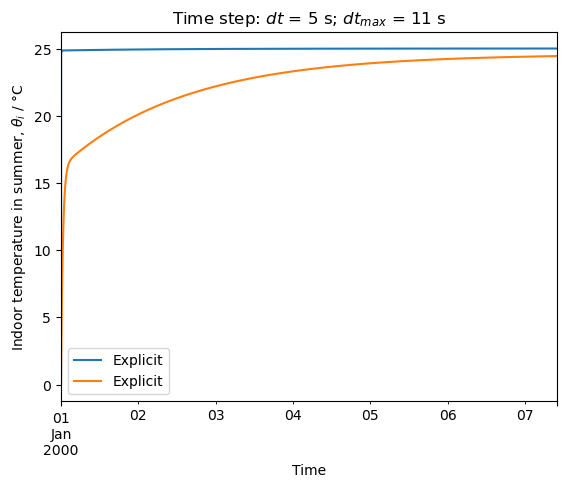

Steady-state indoor temperature for room 1 obtained with:
- DAE model: 25.0162 °C
- state-space model: 25.0162 °C
- steady-state response to step input:           25.0148 °C
Steady-state indoor temperature for room 2 obtained with:
- DAE model: 24.6050 °C
- state-space model: 24.6050 °C
- steady-state response to step input:           24.4529 °C


In [329]:
# plot results
if Euler_explicit:
    y = pd.concat([y_exp_summer], axis=1, keys=['Explicit'])
else:
    y = pd.concat([y_imp_summer], axis=1, keys=['Implicit'])

# Flatten the two-level column labels into a single level
y.columns = y.columns.get_level_values(0)

ax = y.plot()
ax.set_xlabel('Time')
ax.set_ylabel('Indoor temperature in summer, $\\theta_i$ / °C')
ax.set_title(f'Time step: $dt$ = {dt:.0f} s; $dt_{{max}}$ = {Δtmax:.0f} s')
plt.show()

print('Steady-state indoor temperature for room 1 obtained with:')
print(f'- DAE model: {float(θss_summer[0]):.4f} °C')
print(f'- state-space model: {float(yss_summer_1):.4f} °C')
if Euler_explicit:
    print(f'- steady-state response to step input: \
          {y_exp_summer["θ0"].tail(1).values[0]:.4f} °C')
else:
    print(f'- steady-state response to step input: \
          {y_imp_summer["θ0"].tail(1).values[0]:.4f} °C')

print('Steady-state indoor temperature for room 2 obtained with:')
print(f'- DAE model: {float(θss_summer[1]):.4f} °C')
print(f'- state-space model: {float(yss_summer_2):.4f} °C')
if Euler_explicit:
    print(f'- steady-state response to step input: \
          {y_exp_summer["θ1"].tail(1).values[0]:.4f} °C')
else:
    print(f'- steady-state response to step input: \
          {y_imp_summer["θ1"].tail(1).values[0]:.4f} °C')

#### Integration for winter

In [330]:
# Initial conditions
θ0 = 0.0

# Convert DataFrames to NumPy arrays (to avoid long time simulation)
As_np = As.to_numpy(dtype=float)
Bs_np = Bs.to_numpy(dtype=float)
Cs_np = Cs.to_numpy(dtype=float)
Ds_np = Ds.to_numpy(dtype=float)
u_np = u_winter.to_numpy(dtype=float)

# Dimensions
n_steps = u_np.shape[0]
n_states = As_np.shape[0]

# Identity matrix
I = np.eye(n_states)

# Common matrix
N = dt * Bs_np

if Euler_explicit:
    # ======================
    # Explicit Euler
    # ======================

    θ_exp_np = np.zeros((n_steps, n_states), dtype=float)
    θ_exp_np[0, :] = θ0

    # Precompute constant explicit Euler matrix
    M_exp = I + dt * As_np

    # Time integration
    for k in range(n_steps - 1):
        θ_exp_np[k + 1, :] = M_exp @ θ_exp_np[k, :] + N @ u_np[k, :]

    # Convert states back to DataFrame
    θ_exp = pd.DataFrame(
        θ_exp_np,
        index=u_winter.index,
        columns=As.columns
    )

    # Outputs
    y_exp_winter_np = θ_exp_np @ Cs_np.T + u_np @ Ds_np.T

    y_exp_winter = pd.DataFrame(
        y_exp_winter_np,
        index=u_winter.index,
        columns=Cs.index
    )

else:
    # ======================
    # Implicit Euler
    # ======================

    θ_imp_np = np.zeros((n_steps, n_states), dtype=float)
    θ_imp_np[0, :] = θ0

    # Precompute and factorize constant implicit Euler matrix
    M_imp = I - dt * As_np
    lu, piv = lu_factor(M_imp)

    # Time integration
    for k in range(n_steps - 1):
        rhs = θ_imp_np[k, :] + N @ u_np[k, :]
        θ_imp_np[k + 1, :] = lu_solve((lu, piv), rhs)

    # Convert states back to DataFrame
    θ_imp = pd.DataFrame(
        θ_imp_np,
        index=u_winter.index,
        columns=As.columns
    )

    # Outputs
    y_imp_winter_np = θ_imp_np @ Cs_np.T + u_np @ Ds_np.T

    y_imp_winter = pd.DataFrame(
        y_imp_winter_np,
        index=u_winter.index,
        columns=Cs.index
    )

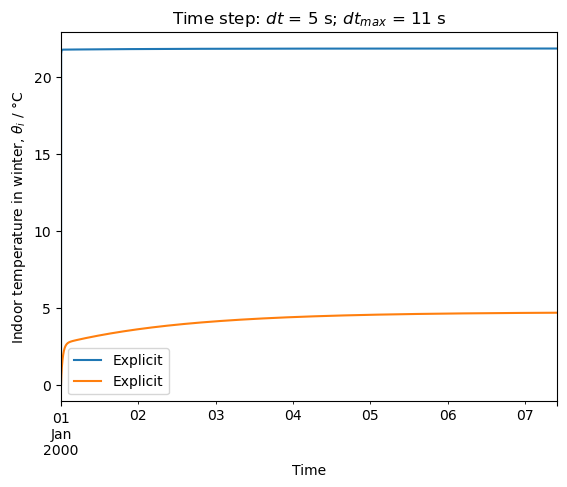

Steady-state indoor temperature for room 1 obtained with:
- DAE model: 21.8679 °C
- state-space model: 21.8679 °C
- steady-state response to step input:           21.8672 °C
Steady-state indoor temperature for room 2 obtained with:
- DAE model: 4.7119 °C
- state-space model: 4.7119 °C
- steady-state response to step input:           4.6729 °C


In [331]:
# plot results
if Euler_explicit:
    y = pd.concat([y_exp_winter], axis=1, keys=['Explicit'])
else:
    y = pd.concat([y_imp_winter], axis=1, keys=['Implicit'])
# Flatten the two-level column labels into a single level
y.columns = y.columns.get_level_values(0)

ax = y.plot()
ax.set_xlabel('Time')
ax.set_ylabel('Indoor temperature in winter, $\\theta_i$ / °C')
ax.set_title(f'Time step: $dt$ = {dt:.0f} s; $dt_{{max}}$ = {Δtmax:.0f} s')
plt.show()

print('Steady-state indoor temperature for room 1 obtained with:')
print(f'- DAE model: {float(θss_winter[0]):.4f} °C')
print(f'- state-space model: {float(yss_winter_1):.4f} °C')
if Euler_explicit:
    print(f'- steady-state response to step input: \
          {y_exp_winter["θ0"].tail(1).values[0]:.4f} °C')
else:
    print(f'- steady-state response to step input: \
          {y_imp_winter["θ0"].tail(1).values[0]:.4f} °C')

print('Steady-state indoor temperature for room 2 obtained with:')
print(f'- DAE model: {float(θss_winter[1]):.4f} °C')
print(f'- state-space model: {float(yss_winter_2):.4f} °C')
if Euler_explicit:
    print(f'- steady-state response to step input: \
          {y_exp_winter["θ1"].tail(1).values[0]:.4f} °C')
else:
    print(f'- steady-state response to step input: \
          {y_imp_winter["θ1"].tail(1).values[0]:.4f} °C')

### Results

In [332]:
if Euler_explicit:
    y_summer = y_exp_summer
    y_winter = y_exp_winter
else:
    y_summer = y_imp_summer
    y_winter = y_imp_winter

results_table = pd.DataFrame({
    "Method": ["DAE", "State Space", "Step Input"],
    "Room 1 Summer θ [°C]": [
        θss_summer[0],
        yss_summer_1,
        y_summer['θ0'].tail(1).values[0]
    ],
    "Room 2 Summer θ [°C]": [
        θss_summer[1],
        yss_summer_2,
        y_summer['θ1'].tail(1).values[0]
    ],
    "Room 1 Winter θ [°C]": [
        θss_winter[0],
        yss_winter_1,
        y_winter['θ0'].tail(1).values[0]
    ],
    "Room 2 Winter θ [°C]": [
        θss_winter[1],
        yss_winter_2,
        y_winter['θ1'].tail(1).values[0]
    ]
})

display(results_table.round(2))

,Method,Room 1 Summer θ [°C],Room 2 Summer θ [°C],Room 1 Winter θ [°C],Room 2 Winter θ [°C]
0,DAE,25.02,24.60,21.87,4.71
1,State Space,25.02,24.60,21.87,4.71
2,Step Input,25.01,24.45,21.87,4.67


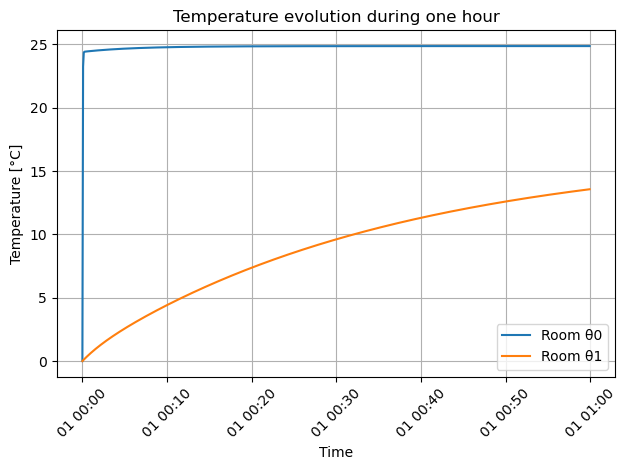

In [333]:
y_instability = y_summer.copy()

# Elegir hora inicial
inicio = pd.Timestamp("2000-01-01 00:00:00", tz=y_instability.index.tz)

# Definir una ventana de 1 hora
fin = inicio + pd.Timedelta(hours=1)

# Filtrar exactamente una hora
y_1h = y_instability.loc[(y_instability.index >= inicio) & (y_instability.index < fin)]

# Graficar ambas columnas
plt.figure()

plt.plot(y_1h.index, y_1h["θ0"], label="Room θ0")
plt.plot(y_1h.index, y_1h["θ1"], label="Room θ1")

plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.title("Temperature evolution during one hour")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Simulation

In [334]:
# Dates for summer
date_start_summer = '2000-08-01'
date_end_summer = '2000-08-05'

# Dates for winter
date_start_winter = '2000-01-01'
date_end_winter = '2000-01-05'

# Weather data
file_weather = 'data/FRA_Lyon.074810_IWEC.epw'
[data, meta] = dm4bem.read_epw(file_weather, coerce_year=None)
weather = data[["temp_air", "dir_n_rad", "dif_h_rad"]]
del data

# select weather data from date_start to date_end
weather.index = weather.index.map(lambda t: t.replace(year=2000))
weather_summer = weather.loc[date_start_summer:date_end_summer]
weather_winter = weather.loc[date_start_winter:date_end_winter]

In [335]:
# Temperature sources
To_summer = weather_summer['temp_air']
To_winter = weather_winter['temp_air']

Ti_day, Ti_night = 20, 16
Ti_sp_summer = pd.Series(20, index=To_summer.index)
Ti_sp_summer = pd.Series(
    [Ti_day if 6 <= hour <= 22 else Ti_night for hour in To_summer.index.hour],
    index=To_summer.index)

Ti_sp_winter = pd.Series(20, index=To_winter.index)
Ti_sp_winter = pd.Series(
    [Ti_day if 6 <= hour <= 22 else Ti_night for hour in To_winter.index.hour],
    index=To_winter.index)

# Flow-rate sources
# total solar irradiance
surface_orientation = {'slope': 0,
                       'azimuth': 0,
                       'latitude': 45}

rad_surf_summer = dm4bem.sol_rad_tilt_surf(
    weather_summer, surface_orientation, 1-α)

Etot_summer = rad_surf_summer.sum(axis=1)

rad_surf_winter = dm4bem.sol_rad_tilt_surf(
    weather_winter, surface_orientation, 1-α)

Etot_winter = rad_surf_winter.sum(axis=1)

# window glass properties
α_gSW = 0.38    # short wave absortivity: reflective blue glass
τ_gSW = 0.30    # short wave transmitance: reflective blue glass

# flow-rate sources:
# solar radiation summer
Φo_summer = α * S_wall_total * Etot_summer#pd.Series(α * S_wall_total * E_summer, index=To_summer.index)
Φi_summer = τ_gSW * α_gSW * S_window * Etot_summer #pd.Series(α * S_wall_total * E_summer, index=To_summer.index)
Φa_summer = pd.Series(0, index=To_summer.index)
# auxiliary (internal) sources
Qa_summer = pd.Series(0, index=To_summer.index)

# solar radiation winter
Φo_winter = α * S_wall_total * Etot_winter #pd.Series(α * S_wall_total * E_winter, index=To_winter.index)
Φi_winter = τ_gSW * α_gSW * S_window * Etot_winter #pd.Series(α * S_wall_total * E_winter, index=To_winter.index) 
Φa_winter = pd.Series(0, index=To_winter.index)
# auxiliary (internal) sources
Qa_winter = pd.Series(0, index=To_winter.index)

# Input data set
input_data_set_sim_summer = pd.DataFrame({'To': To_summer, 'Ti_sp': Ti_sp_summer,
                               'Φo': Φo_summer, 'Φi': Φi_summer, 'Qa': Qa_summer, 'Φa': Φa_summer,
                               'Etot': Etot_summer})

input_data_set_sim_winter = pd.DataFrame({'To': To_winter, 'Ti_sp': Ti_sp_winter,
                               'Φo': Φo_winter, 'Φi': Φi_winter, 'Qa': Qa_winter, 'Φa': Φa_winter,
                               'Etot': Etot_winter})

In [336]:
# Simulation
# ==========

# Convert state-space matrices to NumPy arrays
As_np = As.to_numpy(dtype=float)
Bs_np = Bs.to_numpy(dtype=float)
Cs_np = Cs.to_numpy(dtype=float)
Ds_np = Ds.to_numpy(dtype=float)

# Dimensions
n_states = As_np.shape[0]

# Initial conditions
θ0 = 10.0

# Identity matrix
I = np.eye(n_states)

# Precompute constant matrices for explicit Euler
M_exp = I + dt * As_np
N_exp = dt * Bs_np


def simulate_explicit(input_data_set_case, case_name):
    """
    Resample input data, build input vector u, solve explicit Euler,
    calculate outputs and HVAC heat flux.
    """

    # Resample hourly data to time step dt
    input_resampled = input_data_set_case.resample(
        pd.to_timedelta(dt, unit='s')
    ).interpolate(method='linear')

    # Get input vector in time
    u_case = dm4bem.inputs_in_time(us, input_resampled)

    # Convert input vector to NumPy
    u_np = u_case.to_numpy(dtype=float)

    # Allocate state matrix
    n_steps = u_np.shape[0]
    θ_np = np.zeros((n_steps, n_states), dtype=float)
    θ_np[0, :] = θ0

    # Time integration
    for k in range(n_steps - 1):
        θ_np[k + 1, :] = M_exp @ θ_np[k, :] + N_exp @ u_np[k + 1, :]

    # Convert states back to DataFrame
    θ = pd.DataFrame(
        θ_np,
        index=u_case.index,
        columns=As.columns
    )

    # Outputs
    y_np = θ_np @ Cs_np.T + u_np @ Ds_np.T

    y = pd.DataFrame(
        y_np,
        index=u_case.index,
        columns=Cs.index
    )

    # HVAC heat flux
    q_HVAC = Kp * (u_case['q22'] - y['θ0']) / S_wall_total

    # Data for plots and post-processing
    data = pd.DataFrame({
        'To': input_resampled['To'],
        'θi': y['θ0'],
        'Etot': input_resampled['Etot'],
        'q_HVAC': q_HVAC
    })

    return input_resampled, u_case, θ, y, q_HVAC, data


# Run simulations
input_data_set_sim_summer, u_sim_summer, θ_exp_summer, y_sim_summer, q_HVAC_summer, data_summer = simulate_explicit(
    input_data_set_sim_summer,
    case_name='Summer'
)

input_data_set_sim_winter, u_sim_winter, θ_exp_winter, y_sim_winter, q_HVAC_winter, data_winter = simulate_explicit(
    input_data_set_sim_winter,
    case_name='Winter'
)

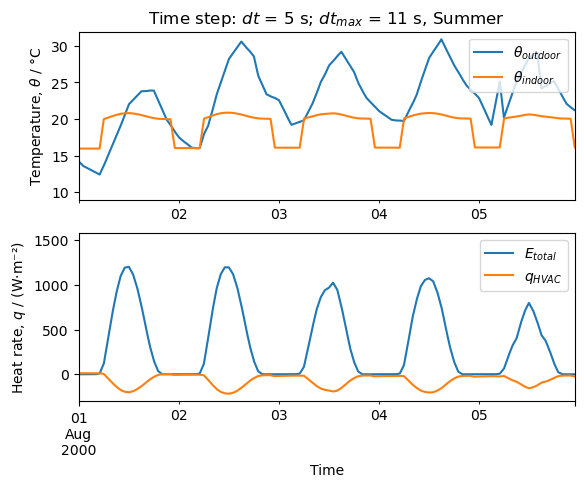

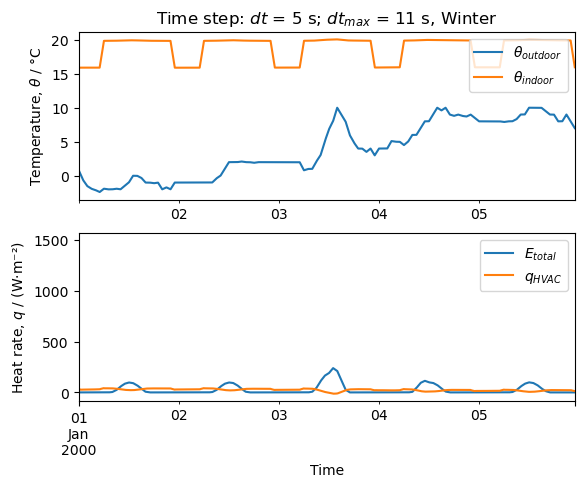

In [337]:
def plot_simulation(data, season):
    fig, axs = plt.subplots(2, 1)

    data[['To', 'θi']].plot(
        ax=axs[0],
        xticks=[],
        ylabel='Temperature, $θ$ / °C'
    )

    axs[0].legend(
        ['$θ_{outdoor}$', '$θ_{indoor}$'],
        loc='upper right'
    )

    data[['Etot', 'q_HVAC']].plot(
        ax=axs[1],
        ylabel='Heat rate, $q$ / (W·m⁻²)'
    )

    axs[1].set(xlabel='Time')

    axs[1].legend(
        ['$E_{total}$', '$q_{HVAC}$'],
        loc='upper right'
    )

    axs[0].set_title(
        f'Time step: $dt$ = {dt:.0f} s; '
        f'$dt_{{max}}$ = {Δtmax:.0f} s, {season}'
    )

    plt.show()


plot_simulation(data_summer, 'Summer')
plot_simulation(data_winter, 'Winter')

In [338]:
def print_results(data, q_HVAC, season):
    print(f'For {season}:')
    dm4bem.print_rounded_time("Time step:", dt)

    print(f"Mean outdoor temperature: {data['To'].mean():.1f} °C")
    print(f"Min. indoor temperature: {data['θi'].min():.1f} °C")
    print(f"Max. indoor temperature: {data['θi'].max():.1f} °C")

    max_load = data['q_HVAC'].max()
    max_load_index = data['q_HVAC'].idxmax()

    Q_heat = q_HVAC[q_HVAC > 0].sum() * dt / 3.6e6
    Q_cool = q_HVAC[q_HVAC < 0].sum() * dt / 3.6e6

    print(f"Max. load: {max_load:.1f} W/m² at {max_load_index}")
    print(f"Energy consumption for heating: {Q_heat:.1f} kWh/m²")
    print(f"Energy consumption for cooling: {Q_cool:.1f} kWh/m²")
    print()


print_results(data_summer, q_HVAC_summer, 'summer')
print_results(data_winter, q_HVAC_winter, 'winter')

For summer:
Time step: = 5 s
Mean outdoor temperature: 22.8 °C
Min. indoor temperature: 10.0 °C
Max. indoor temperature: 20.9 °C
Max. load: 1492.5 W/m² at 2000-08-01 00:00:00+01:00
Energy consumption for heating: 0.1 kWh/m²
Energy consumption for cooling: -8.5 kWh/m²

For winter:
Time step: = 5 s
Mean outdoor temperature: 3.8 °C
Min. indoor temperature: 10.0 °C
Max. indoor temperature: 20.1 °C
Max. load: 1492.5 W/m² at 2000-01-01 00:00:00+01:00
Energy consumption for heating: 3.0 kWh/m²
Energy consumption for cooling: -0.0 kWh/m²

